# Real-TabPFN — GP2 Tabular SSL Research

**Student:** Zain Qerba (160201)  
**Supervisor:** Dana El Rushaidat  
**University:** Jordan University of Science and Technology  

---

## Purpose
This notebook evaluates **Real-TabPFN (TabPFN v2)** on the California Housing regression task
at 8 data fractions (100%, 50%, 10%, 8%, 6%, 4%, 2%, 1%).

Real-TabPFN is a **foundation model** pretrained on millions of synthetic tabular datasets
using Bayesian priors. It requires no training at inference time — the labeled fraction is
passed as in-context examples in a single forward pass with no gradient updates.

This makes it fundamentally different from TabNet and SAINT: instead of SSL pretraining
on the target dataset, Real-TabPFN transfers knowledge from its large-scale synthetic
pretraining directly. We compare it against XGBoost to find the crossover point where
a foundation model outperforms tree-based methods as labeled data decreases.

## Dataset
| Dataset | Task | Rows | Features |
|---|---|---|---|
| California Housing | Regression | 20,640 | 8 |

## Metrics
- **RMSE** — Root Mean Squared Error (lower is better)
- **MAE** — Mean Absolute Error (lower is better)
- **R²** — Coefficient of determination (higher is better)

## Citation
Hollmann, N., Müller, S., Purucker, L., Krishnakumar, A., Körfer, M., Hoo, S. B.,
Schirrmeister, R. T., & Hutter, F. (2025).
TabPFN v2: Improved In-Context Learning for Tabular Data.
*arXiv:2501.02945*. https://arxiv.org/abs/2501.02945

In [1]:
# ── Cell 1: TabPFN API Token ───────────────────────────────────────────────────
# Required for TabPFN v2 — register once at ux.priorlabs.ai to get your token

import os
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_M_Pjq6pxBD-uUTCYlmAaZr6RGRqp8FZKmMUZ5L0wCuU"

In [2]:
# ── Cell 2: Install Dependencies ──────────────────────────────────────────────
# tabpfn       — Real-TabPFN v2 foundation model

!pip install tabpfn --upgrade scikit-learn pandas numpy matplotlib seaborn -q
print("All packages installed successfully.")

All packages installed successfully.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ── Cell 3: Imports & Config ───────────────────────────────────────────────────
# No hyperparameters to tune — TabPFN uses in-context learning.
# n_estimators=8 means 8 ensemble members for more stable predictions.
# ignore_pretraining_limits=True allows datasets larger than TabPFN's default limit.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tabpfn import TabPFNRegressor

RANDOM_STATE = 42
FRACTIONS    = [1.0, 0.5, 0.1, 0.08, 0.06, 0.04, 0.02, 0.01]
RESULTS_FILE = '../results/realtabpfn_results.csv'

In [4]:
# ── Cell 4: Load Data & Train/Test Split ───────────────────────────────────────
# Standard 80/20 split — no stratification needed for regression.
# TabPFN does NOT need StandardScaler — it handles normalization internally.

print("Loading California Housing dataset...")
housing = fetch_california_housing()
X_all   = housing.data.astype(np.float32)
y_all   = housing.target.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Full train : {X_train.shape}")
print(f"Test       : {X_test.shape}")
print(f"Target range: {y_all.min():.2f} — {y_all.max():.2f}")

Loading California Housing dataset...
Full train : (16512, 8)
Test       : (4128, 8)
Target range: 0.15 — 5.00


In [5]:
# ── Cell 5: Helper Functions ───────────────────────────────────────────────────

def save_result(row):
    # Append result to CSV, overwriting any existing row for same dataset+fraction
    df_new = pd.DataFrame([row])
    if os.path.exists(RESULTS_FILE):
        df_existing = pd.read_csv(RESULTS_FILE)
        df_existing = df_existing[~(
            (df_existing['dataset'] == row['dataset']) &
            (df_existing['fraction'] == row['fraction'])
        )]
        df_new = pd.concat([df_existing, df_new], ignore_index=True)
    df_new.to_csv(RESULTS_FILE, index=False)

def get_completed_fractions():
    # Returns already-completed fractions to allow resuming interrupted runs
    if not os.path.exists(RESULTS_FILE):
        return []
    df = pd.read_csv(RESULTS_FILE)
    return df[df['dataset'] == 'california_housing']['fraction'].tolist()

In [6]:
# ── Cell 6: Training Loop ──────────────────────────────────────────────────────
# For each fraction:
#   1. Subsample training data
#   2. Fit TabPFN — no gradient updates, just in-context learning
#   3. Predict on full test set
#   4. Compute RMSE, MAE, R² and save

print("=" * 60)
print("CALIFORNIA HOUSING — Real-TabPFN across 8 data fractions")
print("=" * 60)

completed = get_completed_fractions()

for frac in FRACTIONS:
    if frac in completed:
        print(f"\nFraction: {int(frac*100)}% — already done, skipping")
        continue

    print(f"\nFraction: {int(frac*100)}%")

    if frac == 1.0:
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        n_samples = int(len(X_train) * frac)
        _, X_tr, _, y_tr = train_test_split(
            X_train, y_train,
            test_size=n_samples,
            random_state=RANDOM_STATE
        )

    print(f"  Training samples: {len(X_tr):,}")

    # no StandardScaler — TabPFN normalizes internally
    model = TabPFNRegressor(
        device='cuda',
        random_state=RANDOM_STATE,
        ignore_pretraining_limits=True,
        n_estimators=8,
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"  TEST → RMSE: {rmse:.4f}  |  MAE: {mae:.4f}  |  R²: {r2:.4f}")

    save_result({
        'dataset': 'california_housing',    # fixed: was 'california'
        'model': 'realtabpfn', 'fraction': frac,
        'n_train_samples': len(X_tr),
        'accuracy': None, 'macro_f1': None,
        'roc_auc': None, 'pr_auc': None, 'f1': None,
        'rmse': round(rmse, 4), 'mae': round(mae, 4), 'r2': round(r2, 4),
        'best_optuna_params': 'TabPFN default — no hyperparameters'
    })
    print(f"  Saved: dataset=california_housing | fraction={frac}")

print("\nCalifornia Housing Real-TabPFN experiments complete.")

CALIFORNIA HOUSING — Real-TabPFN across 8 data fractions

Fraction: 100%
  Training samples: 16,512
  TEST → RMSE: 0.3905  |  MAE: 0.2357  |  R²: 0.8836
  Saved: dataset=california_housing | fraction=1.0

Fraction: 50%
  Training samples: 8,256
  TEST → RMSE: 0.4088  |  MAE: 0.2475  |  R²: 0.8725
  Saved: dataset=california_housing | fraction=0.5

Fraction: 10%
  Training samples: 1,651
  TEST → RMSE: 0.4632  |  MAE: 0.2935  |  R²: 0.8363
  Saved: dataset=california_housing | fraction=0.1

Fraction: 8%
  Training samples: 1,320
  TEST → RMSE: 0.4829  |  MAE: 0.3087  |  R²: 0.8220
  Saved: dataset=california_housing | fraction=0.08

Fraction: 6%
  Training samples: 990
  TEST → RMSE: 0.4922  |  MAE: 0.3178  |  R²: 0.8151
  Saved: dataset=california_housing | fraction=0.06

Fraction: 4%
  Training samples: 660
  TEST → RMSE: 0.5153  |  MAE: 0.3342  |  R²: 0.7974
  Saved: dataset=california_housing | fraction=0.04

Fraction: 2%
  Training samples: 330
  TEST → RMSE: 0.5634  |  MAE: 0.3774

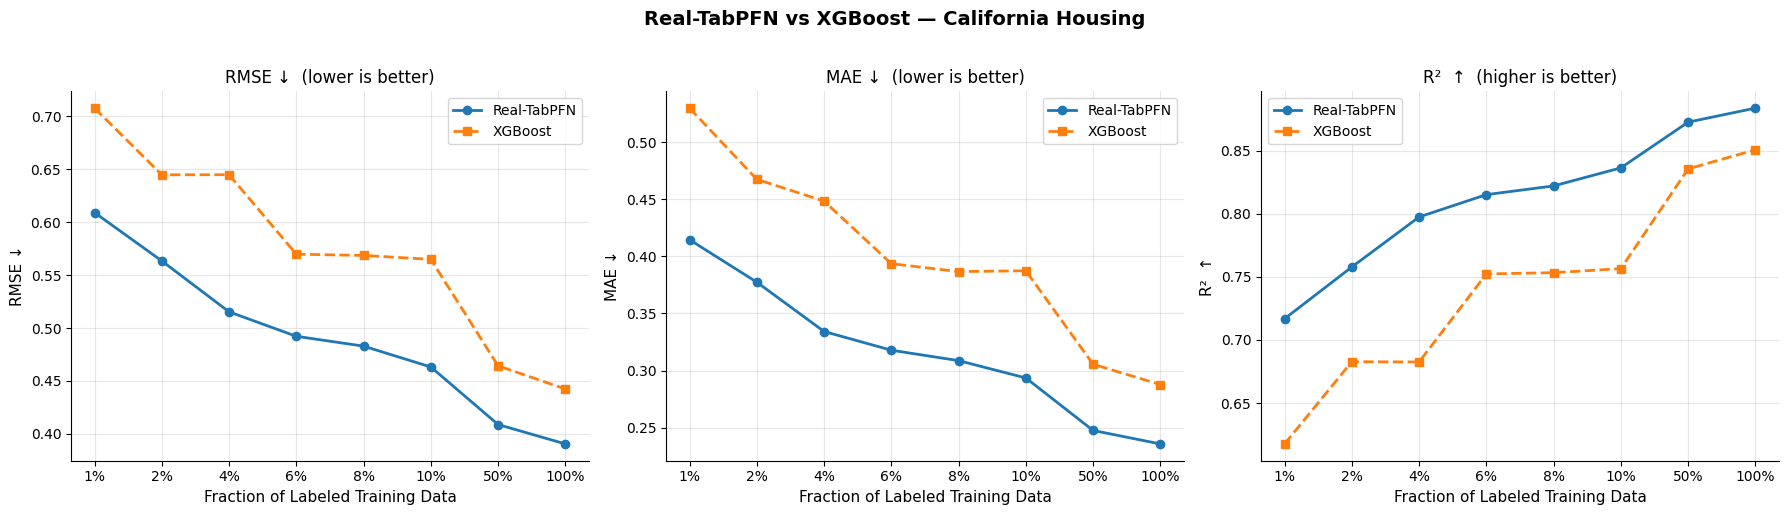

Plot saved.


In [7]:
# ── Cell 7: Visualization — Real-TabPFN vs XGBoost on California Housing ───────
# 3 subplots: RMSE, MAE, R²
# Evenly spaced x-axis so small fractions (1%-10%) don't crowd together.

tab_cal = pd.read_csv('../results/realtabpfn_results.csv')
tab_cal = tab_cal[tab_cal['dataset'] == 'california_housing'].sort_values('fraction').reset_index(drop=True)

xgb_cal = pd.read_csv('../results/xgboost_results.csv')
xgb_cal = xgb_cal[xgb_cal['dataset'] == 'california_housing'].sort_values('fraction').reset_index(drop=True)

x_pos    = np.arange(len(tab_cal))
x_labels = [f"{int(f*100)}%" for f in tab_cal['fraction'].values]

BLUE   = '#1f77b4'
ORANGE = '#ff7f0e'

metrics = [
    ('rmse', 'RMSE ↓', 'lower is better'),
    ('mae',  'MAE ↓',  'lower is better'),
    ('r2',   'R²  ↑',  'higher is better'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Real-TabPFN vs XGBoost — California Housing', fontsize=14, fontweight='bold', y=1.02)

for ax, (col, ylabel, note) in zip(axes, metrics):
    ax.plot(x_pos, tab_cal[col].values,
            marker='o', linewidth=2, color=BLUE, label='Real-TabPFN')
    ax.plot(x_pos, xgb_cal[col].values,
            marker='s', linewidth=2, color=ORANGE, linestyle='--', label='XGBoost')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_xlabel('Fraction of Labeled Training Data', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel}  ({note})', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/realtabpfn_california_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")